    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [24]:
inds_10 = pd.read_csv('csv/10_industry.csv')
inds_10['Date'] = pd.to_datetime(inds_10['Date'])
inds_10 = inds_10.set_index('Date')
inds_10.info()
inds_10

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NoDur   6539 non-null   float64
 1   Durbl   6539 non-null   float64
 2   Manuf   6539 non-null   float64
 3   Enrgy   6539 non-null   float64
 4   HiTec   6539 non-null   float64
 5   Telcm   6539 non-null   float64
 6   Shops   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Utils   6539 non-null   float64
 9   Other   6539 non-null   float64
dtypes: float64(10)
memory usage: 561.9 KB


,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
2000-01-03,-1.65,-1.36,-2.49,-3.08,2.47,-1.26,-2.30,-0.58,-2.37,-3.31
2000-01-04,-1.81,-2.60,-2.68,-1.96,-5.34,-4.40,-3.28,-4.39,0.47,-3.68
2000-01-05,-0.13,-0.04,0.57,2.26,-1.09,0.01,-0.38,2.32,3.48,-0.38
2000-01-06,0.68,0.58,2.17,4.00,-4.93,-1.92,0.24,2.68,0.57,2.34
2000-01-07,2.11,4.81,3.21,1.16,3.51,0.93,4.27,7.61,1.13,1.99
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.36,0.00,0.46,-0.33,0.17,0.64,0.51,0.58,0.38,0.42
2025-12-26,-0.07,-1.65,-0.13,-0.30,0.09,-0.18,0.13,-0.05,-0.16,-0.05
2025-12-29,0.19,-2.68,-0.38,1.02,-0.40,0.43,-0.21,-0.26,0.26,-0.57


In [32]:
# ── 고정 파라미터 ──
gamma = 0.0    # regularization 제거
x_min = 0.0
x_max = 1.0   # box constraint 제거

N_STOCKS = len(inds_10.columns)

HORIZON    = 21
N          = HORIZON
M          = N_STOCKS   # 10
C          = 1.0
d          = 1.0
lam        = 0.3
delta      = 20          # risk aversion
HIDDEN_DIM = 128
EPOCHS     = 50
BATCH_SIZE = 16
LR         = 1e-4

# ── 실험 grid ──
LOOKBACK_LIST = [252, 504]
N1_LIST       = [0.3, 0.4, 0.5]

configs = [
    {"LOOKBACK": lb, "n1": n1}
    for lb in LOOKBACK_LIST
    for n1 in N1_LIST
]



In [ ]:
inds_10 = inds_10.sort_index()
inds_10 = inds_10[~inds_10.index.duplicated(keep='first')]
inds_10 = inds_10 / 100.0

stock_names = inds_10.columns.tolist()

# =============================================================================
# 2. Train / Val / Test 분리 (날짜 기준)
# =============================================================================
TRAIN_START = "2000-01-01"
TRAIN_END   = "2012-12-31"   # Train : 13년
VAL_START   = "2013-01-01"
VAL_END     = "2017-12-31"   # Val   :  5년
BT_START    = "2018-01-01"
BT_END      = "2025-12-31"   # Test  :  8년

train_df = inds_10[TRAIN_START : TRAIN_END]
val_df   = inds_10[VAL_START   : VAL_END]
bt_df    = inds_10[BT_START    : BT_END]

train_np = train_df.values
val_np   = val_df.values
bt_np    = bt_df.values

N_TRAIN = len(train_df)
N_VAL   = len(val_df)
N_BT    = len(bt_df)
N_DAYS  = len(inds_10)

print(f"전체  : {inds_10.index[0].date()} → {inds_10.index[-1].date()}  ({N_DAYS} days)")
print(f"Train : {train_df.index[0].date()} → {train_df.index[-1].date()}  ({N_TRAIN} days)")
print(f"Val   : {val_df.index[0].date()} → {val_df.index[-1].date()}  ({N_VAL} days)")
print(f"BT    : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목  : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
# Train 기간 통계로 표준화 (변수명 is_mean/is_std 유지 — .py 파일 호환)
is_mean = train_np.mean(axis=0)   # shape (10,)
is_std  = train_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (lookback, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # Train 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

full_np       = np.vstack([train_np, val_np, bt_np])
VAL_START_IDX = N_TRAIN
BT_START_IDX  = N_TRAIN + N_VAL

for cfg in configs:
    LOOKBACK  = cfg["LOOKBACK"]
    n1        = cfg["n1"]
    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    print(f"\n[LOOKBACK={LOOKBACK}, n1={n1}]")
    print(f"  Train 학습 샘플 수  : {len(train_samples)}")
    print(f"  Val 전체 샘플 수    : {len(val_samples)}")
    print(f"  BT 리밸런싱 횟수    : {len(rebal_samples)}")

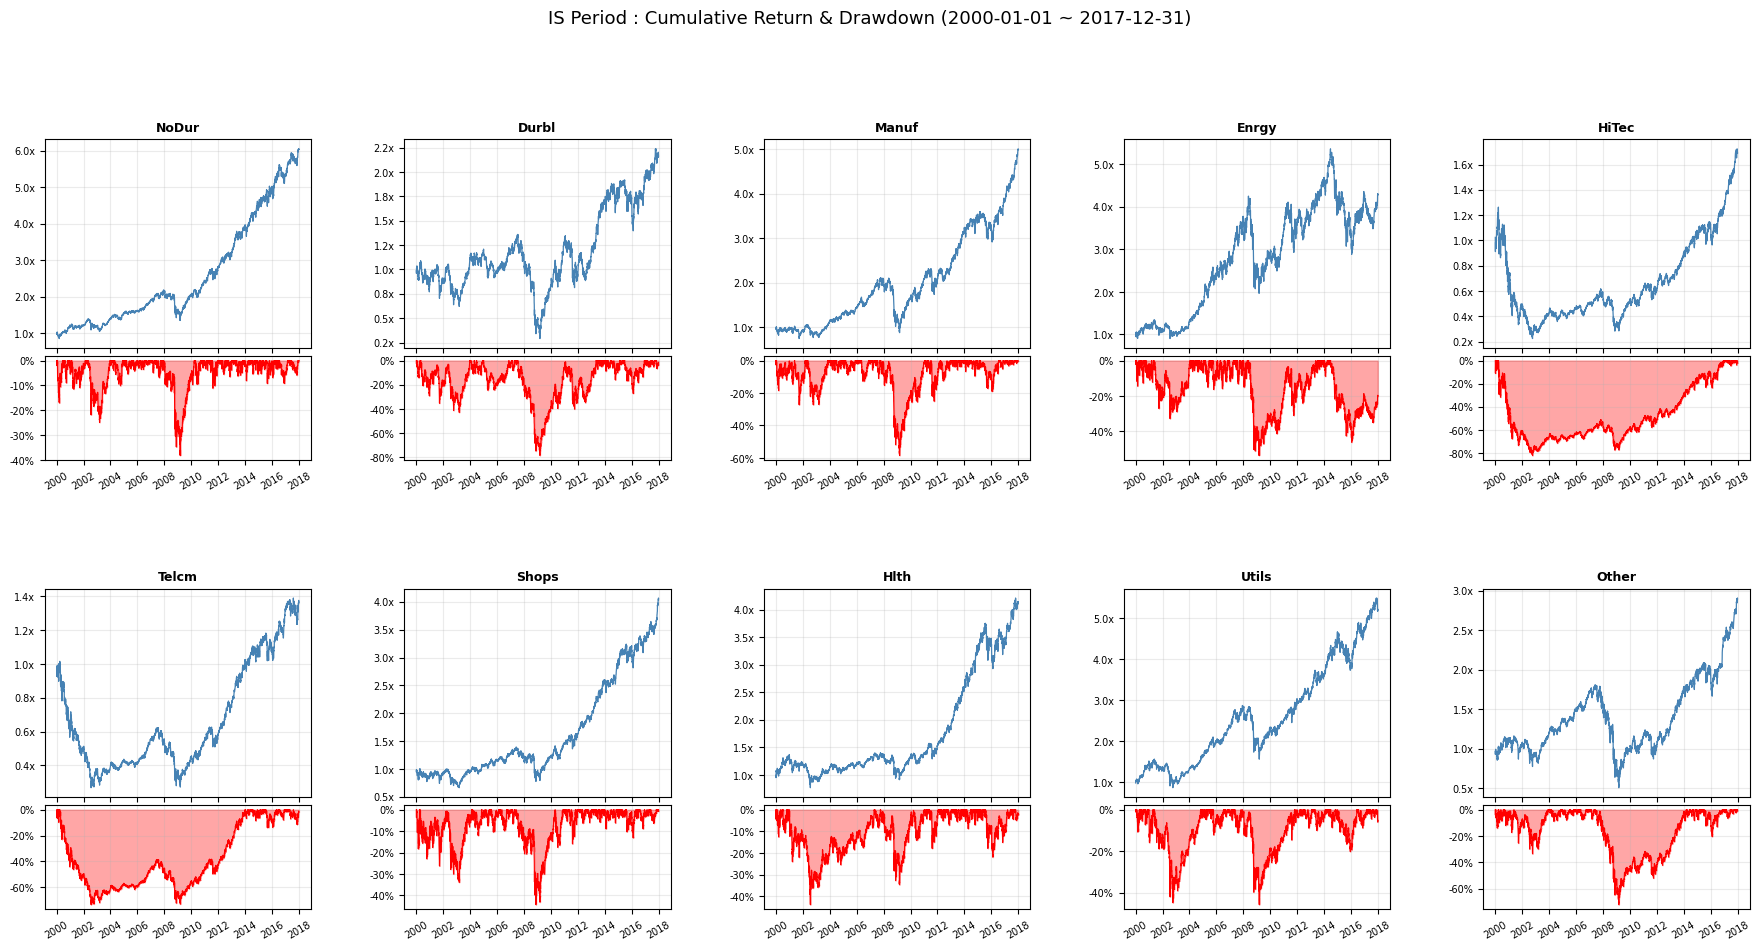

In [27]:
is_cum = (1 + is_df).cumprod()
is_dd  = (is_cum - is_cum.cummax()) / is_cum.cummax()

cols   = is_cum.columns.tolist()  # 10개 종목
N_COLS = 5
N_ROWS = 2  # 종목 행

fig = plt.figure(figsize=(22, 10))
outer = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.4, wspace=0.35)

for i, col in enumerate(cols):
    row, c = divmod(i, N_COLS)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[row, c],
        hspace=0.05, height_ratios=[2, 1]
    )

    ax_ret = fig.add_subplot(inner[0])
    ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

    # 상단: 누적 수익률
    ax_ret.plot(is_cum.index, is_cum[col], color="steelblue", linewidth=0.9)
    ax_ret.set_title(col, fontsize=9, fontweight="bold")
    ax_ret.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.1f}x"))
    ax_ret.tick_params(axis="x", labelbottom=False)
    ax_ret.tick_params(labelsize=7)
    ax_ret.grid(True, alpha=0.25)

    # 하단: Drawdown
    ax_dd.fill_between(is_dd.index, is_dd[col], 0, alpha=0.35, color="red")
    ax_dd.plot(is_dd.index, is_dd[col], color="red", linewidth=0.8)
    ax_dd.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    ax_dd.tick_params(labelsize=7)
    ax_dd.tick_params(axis="x", rotation=30)
    ax_dd.grid(True, alpha=0.25)

fig.suptitle(f"IS Period : Cumulative Return & Drawdown ({IS_START} ~ {IS_END})",
             fontsize=13, y=1.01)
plt.show()


In [28]:
def plot_multi_pnl(results_list, figsize=(14, 8)):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                   gridspec_kw={"height_ratios": [3, 1]},
                                   sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    for (bt_results, label), color in zip(results_list, colors):
        pv = [1.0]
        for res in bt_results:
            w    = res["w_real"]
            base = pv[-1]
            pv.extend((base * (1 + w)).tolist())

        pv          = np.array(pv)
        running_max = np.maximum.accumulate(pv)
        drawdown    = (running_max - pv) / (running_max + 1e-10)
        total_ret   = pv[-1] - 1.0
        max_dd      = drawdown.max()
        calmar      = total_ret / (max_dd + 1e-10)

        full_label = f"{label}  R:{total_ret:.1%}  MDD:{max_dd:.1%}  Cal:{calmar:.2f}"
        ax1.plot(np.arange(len(pv)), pv, color=color, linewidth=1.5, label=full_label)
        ax2.plot(np.arange(len(pv)), -drawdown * 100, color=color, linewidth=1.0, alpha=0.7)

    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.set_ylabel("Portfolio Value")
    ax1.set_title("Cumulative PnL Comparison")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.25)

    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Trading Days (BT Period)")
    ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()



In [ ]:
import importlib
import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel, build_optimization_layer, solve_portfolio,
    compute_cumulative_path, compute_realized_path, compute_return,
    compute_max_drawdown, dfl_loss, forward_pass,
    train_dfl_mdd, backtest_dfl_mdd, plot_pnl,
)

all_results_dfl_mdd = []

for cfg in configs:
    LOOKBACK = cfg["LOOKBACK"]
    n1       = cfg["n1"]

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={LOOKBACK}, n1={n1}")
    print(f"{'='*60}")

    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    val_samples   = val_samples[::HORIZON]    # 리밸런싱 간격으로 서브샘플 (속도)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    opt_layer  = build_optimization_layer(N, M, gamma, delta=delta)

    train_dfl_mdd(
        pred_model, opt_layer, train_samples, val_samples,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
        n1=n1, C=C, d=d, x_min=x_min, x_max=x_max, lam=lam,
        is_mean=is_mean, is_std=is_std, delta=delta,
        patience=10,
    )

    bt_dfl_mdd = backtest_dfl_mdd(
        pred_model=pred_model, opt_layer=opt_layer,
        rebal_samples=rebal_samples, N=HORIZON, d=d, C=C,
        n1=n1, x_min=x_min, x_max=x_max,
        delta=delta, is_mean=is_mean, is_std=is_std,
        stock_names=stock_names,
    )
    all_results_dfl_mdd.append((bt_dfl_mdd, f"DFL-MDD (LB={LOOKBACK}, n1={n1})"))

plot_multi_pnl(all_results_dfl_mdd)

In [ ]:
import importlib
import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd import train_pto_mdd, backtest_pto_mdd

all_results_pto_mdd = []

for cfg in configs:
    LOOKBACK = cfg["LOOKBACK"]
    n1       = cfg["n1"]

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={LOOKBACK}, n1={n1}")
    print(f"{'='*60}")

    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    train_pto_mdd(model_pto_mdd, train_samples, val_samples,
                  EPOCHS, BATCH_SIZE, LR, patience=10)

    bt_pto_mdd = backtest_pto_mdd(
        model_pto_mdd, rebal_samples, N, d, C,
        n1=n1, x_min=x_min, x_max=x_max, gamma=gamma,
        delta=delta,
        is_mean=is_mean, is_std=is_std,
        stock_names=stock_names,
    )
    all_results_pto_mdd.append((bt_pto_mdd, f"PTO-MDD (LB={LOOKBACK}, n1={n1})"))

plot_multi_pnl(all_results_pto_mdd)

In [ ]:
import importlib
import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo import train_pto_mvo, backtest_pto_mvo

all_results_mvo = []

for lookback in LOOKBACK_LIST:

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={lookback}")
    print(f"{'='*60}")

    INPUT_DIM = lookback * N_STOCKS

    train_samples = make_windows(full_np, lookback, HORIZON,
                                 start=lookback, end=N_TRAIN)
    val_samples   = make_windows(full_np, lookback, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, lookback, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    train_pto_mvo(model_pto_mvo, train_samples, val_samples,
                  EPOCHS, BATCH_SIZE, LR, patience=10)

    bt_pto_mvo = backtest_pto_mvo(
        model_pto_mvo, rebal_samples, N, d, C,
        delta=delta,
        x_min=x_min, x_max=x_max, gamma=gamma,
        is_mean=is_mean, is_std=is_std,
        stock_names=stock_names,
    )
    all_results_mvo.append((bt_pto_mvo, f"PTO-MVO (LB={lookback})"))

plot_multi_pnl(all_results_mvo)